# Imports

In [6]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from PIL import Image
from scipy.signal import convolve2d
import cv2

# Methods

In [20]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum

# Parameters

In [32]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

## a) uma solução aplicada no domínio da frequência

### 1.1) Leitura

In [37]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

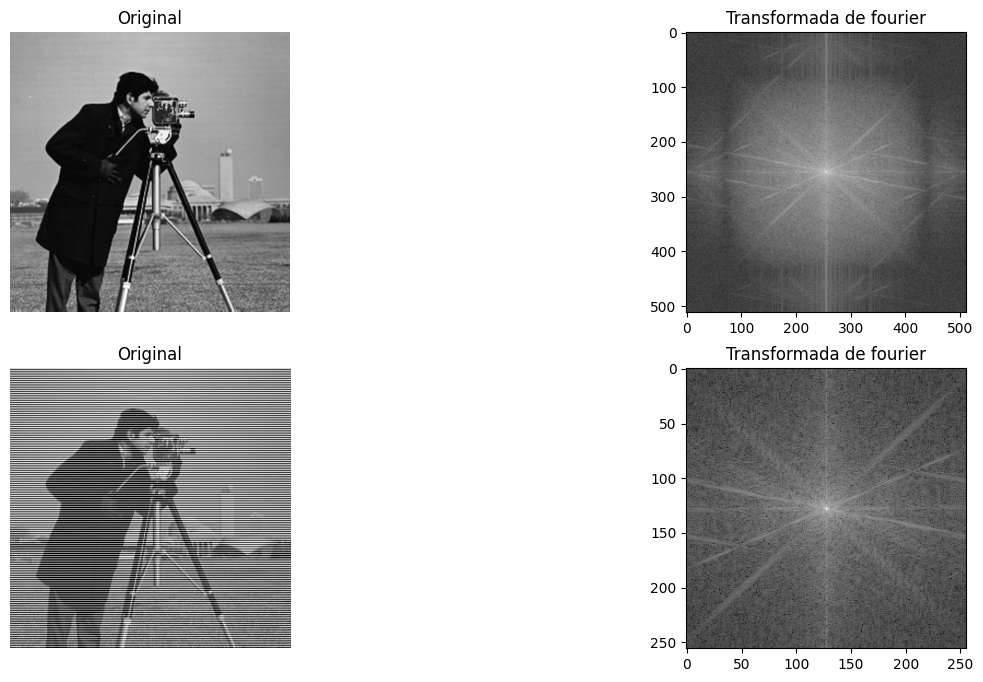

In [41]:
fourier = {
    name: apply_fourier_transform(img) for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 8))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name], cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    _ax[0].axis('off')
    #_ax[1].axis('off')
plt.show()


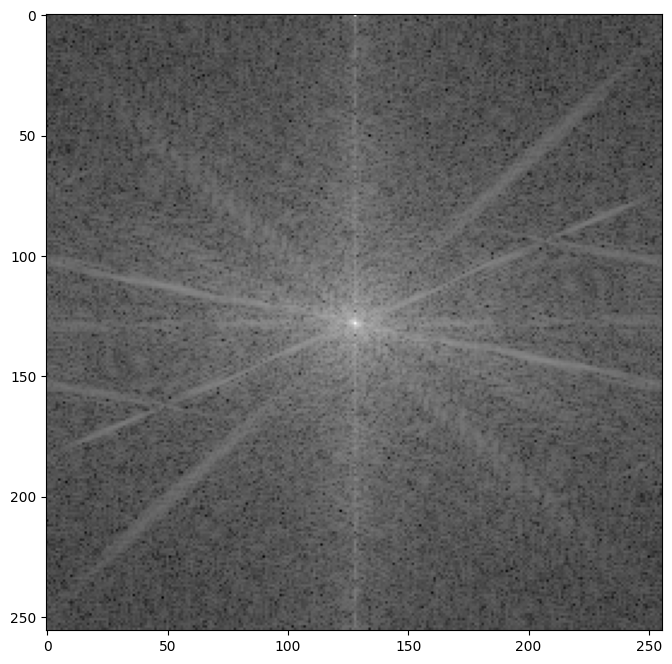

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(fourier["cameraman_pattern"], cmap='gray')

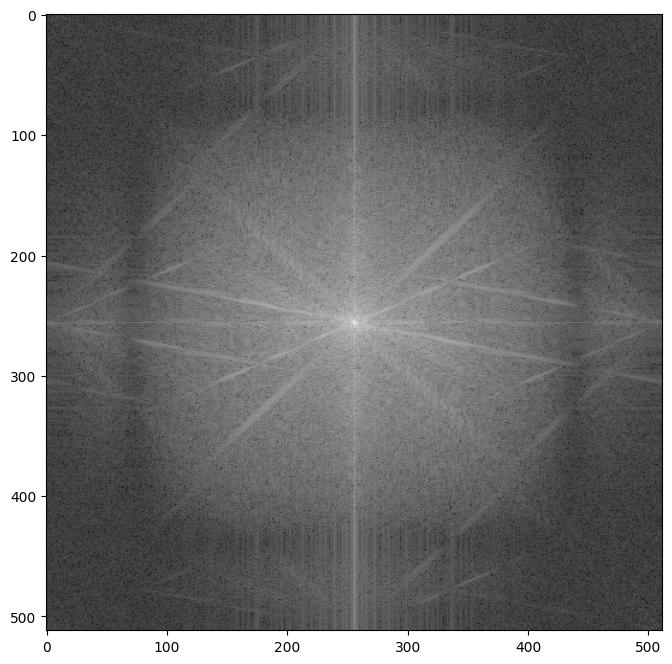

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(fourier["cameraman"], cmap='gray')

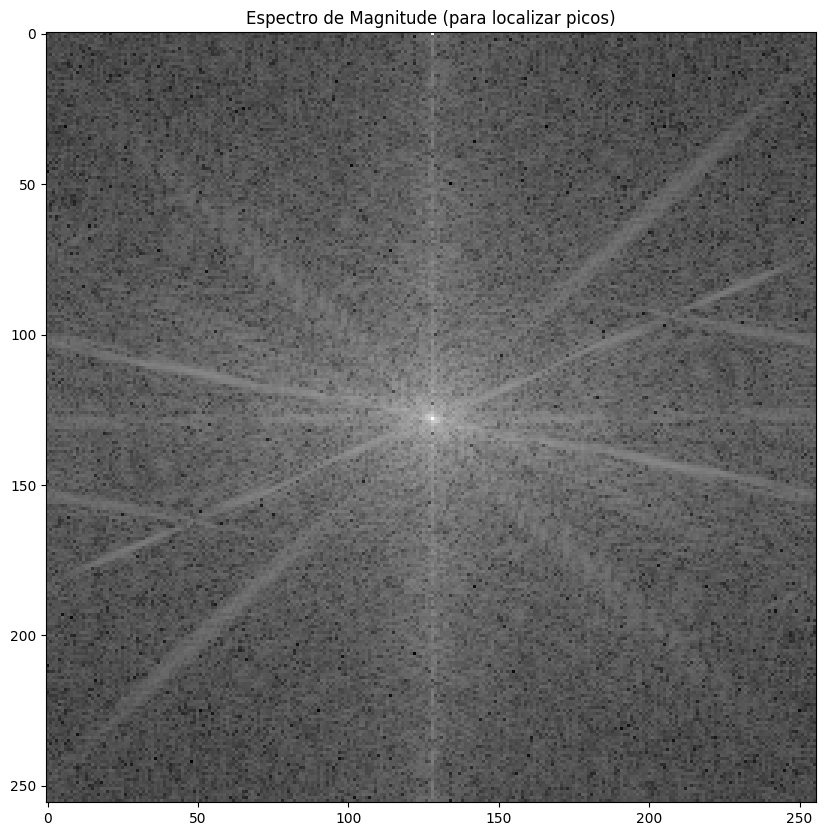

In [19]:
# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude = np.log(np.abs(fshift) + 1)

# Mostrar o espectro em alta resolução
plt.figure(figsize=(10, 10))
plt.imshow(magnitude, cmap='gray')
plt.title("Espectro de Magnitude (para localizar picos)")
plt.show()

## b) uma solução aplicada no domínio espacial